
# 15. MK1: 부품들을 하나로 (칠판 + 통합 시험)

지금까지 키운 부품(읽기, 신뢰, 호기심, 생각, 연결, 사령탑)을 **MK1 하나**로 묶었다.

- **칠판**: 부품끼리 서로 부르지 않고, 이름 붙은 칸에 쓰고 읽는다. 칸의 주소는 구조로 정하고, 내용은 부품이 낸다.
- **동등성**: 칠판을 거쳐도 1·2·3·4·7단계 졸업 점수가 하나도 안 바뀐다.
- **통합 시험**: 종류를 섞은 문제 7,000개를 종류를 알려주지 않고 MK1 하나에 넘겼다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
r = json.loads((S.RESULTS / "mk1-c_integration.json").read_text(encoding="utf-8"))
KINDS = [("T", "T: 사람 말로 푸는 문"), ("C", "C: 안내판이 알려주는 사슬"), ("TC", "TC: 사람 말 + 사슬"), ("board-only", "안내판만 (긴 사슬, 모름)")]
print(json.dumps(r["criteria"], ensure_ascii=False), "graduated:", r["graduated"])


{"1_mixing_breaks_nothing": true, "2a_asking_pays_on_T": true, "2b_no_drop_elsewhere": true} graduated: True



## 1. 칠판을 거쳐도 졸업 점수는 그대로

| 시험 | 졸업 점수 | 칠판을 거친 MK1 |
|---|---:|---:|
| 1단계 신뢰 + 말투 | 0.4148 | 0.4148 |
| 2단계 호기심 | 0.5311 | 0.5311 |
| 3단계 생각 | 0.9750 | 0.9750 |
| 4단계 연결 | 0.4485 | 0.4485 |
| 7단계 사령탑 | 0.4109 | 0.4109 |

부품은 학습 때 쓰던 미리 계산한 표를 불러오지 않는다. 칠판에 올라온 실시간 읽기만 쓴다.



## 2. 섞인 세계: 호기심을 켜면 T가 오른다


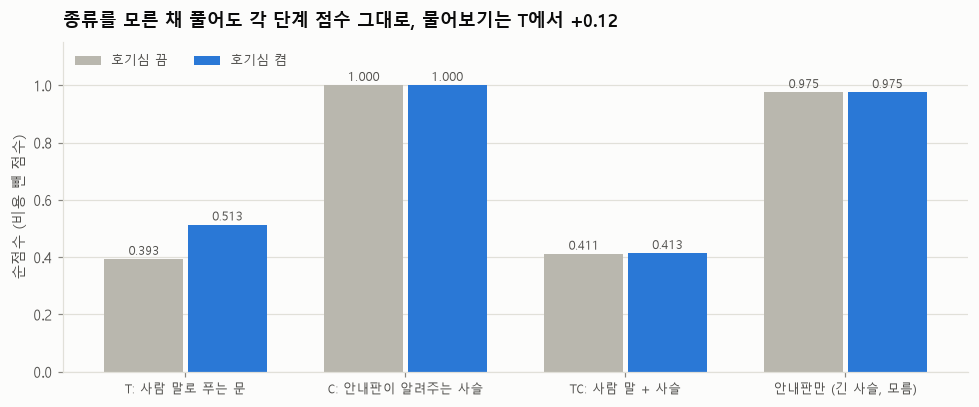

In [2]:

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(KINDS))
w = 0.36
off = [r["by_kind"][k]["off"] for k, _ in KINDS]
on = [r["by_kind"][k]["on"] for k, _ in KINDS]
ax.bar(x - w / 2 - 0.01, off, width=w, color=V.NEUTRAL, label="호기심 끔")
ax.bar(x + w / 2 + 0.01, on, width=w, color=V.BLUE, label="호기심 켬")
for xi, a, b in zip(x, off, on):
    ax.text(xi - w / 2 - 0.01, a + 0.015, f"{a:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
    ax.text(xi + w / 2 + 0.01, b + 0.015, f"{b:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [label for _, label in KINDS], fontsize=8.5)
ax.set_ylim(0, 1.15)
ax.grid(axis="x", visible=False)
ax.set_ylabel("순점수 (비용 뺀 점수)")
ax.legend(fontsize=8.5, frameon=False, loc="upper left", ncol=2)
ax.set_title("종류를 모른 채 풀어도 각 단계 점수 그대로, 물어보기는 T에서 +0.12", pad=10)
fig.tight_layout()
plt.show()



## 3. 속도: 병목은 읽기

생각·판단 부품은 아주 빠르다. 처음 보는 문장을 읽는 얼린 읽기 부품이 약 2,000배 느리다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


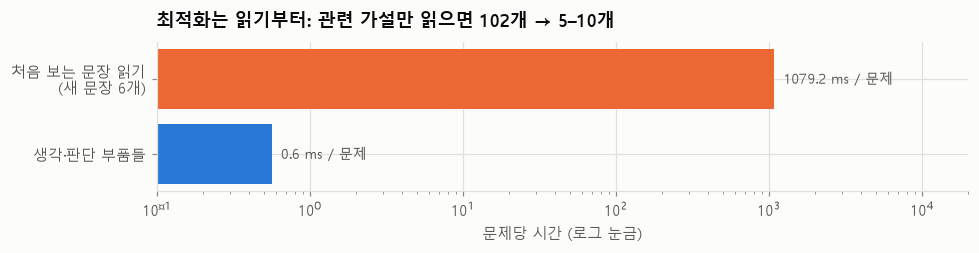

{'curiosity-off': 1959.5, 'curiosity-on': 1777.3, 'gate-off (diagnostic)': 2085.1} peak GPU MB 1172


In [3]:

think_ms = 1000 / r["runs"]["curiosity-on"]["problems_per_second"]
read_ms = 6 * 102 / r["cold_reader_pairs_per_second"] * 1000  # 새 문장 6개 x 가설 102개
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.barh([1, 0], [read_ms, think_ms], color=[V.ORANGE, V.BLUE])
ax.set_yticks([1, 0], ["처음 보는 문장 읽기\n(새 문장 6개)", "생각·판단 부품들"])
ax.set_xscale("log")
for y, v in ((1, read_ms), (0, think_ms)):
    ax.text(v * 1.15, y, f"{v:.1f} ms / 문제", va="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.set_xlim(0.1, 20000)
ax.set_xlabel("문제당 시간 (로그 눈금)")
ax.set_title("최적화는 읽기부터: 관련 가설만 읽으면 102개 → 5–10개", pad=10)
fig.tight_layout()
plt.show()
print({k: v["problems_per_second"] for k, v in r["runs"].items()}, "peak GPU MB", r["runs"]["curiosity-on"]["peak_gpu_mb"])



## 4. 정리

- **MK1 통합 A·B·C 졸업.** 부품 9개의 명함을 만들고 졸업 시험을 자동으로 다시 잰다(A). 칠판으로 연결해도 점수가 그대로다(B). 섞인 세계에서 MK1 하나가 종류도 모른 채 풀고, 섞어도 아무것도 안 깨진다(C).
- **물어보기는 전체 안에서도 이득이다**: T +0.12 (95% 구간 +0.09 ~ +0.15).
- **간접 도움의 신호**: TC에서는 묻지 못하는데도 +0.002. 더 물어 들은 말이 "누가 맞는지" 기억을 낫게 했을 수 있다. 아직 확실하지 않다(구간이 0을 포함).
- **규칙 하나를 배웠다**: "들은 게 없는 부품에는 묻지 않는다." 규칙을 끄면 빈 부품에 묻느라 비용만 쓴다.
- **다음**: D. 실제 한국어 글 부품(읽기 전문가, 실제 글 신뢰)을 칠판에 끼운다. 그리고 읽기 최적화.
